# Bitcoin Proof of Work Analysis

This notebook investigates the time, energy, and security aspects of Bitcoin mining using the Proof of Work (PoW) strategy.

In [45]:
# imports
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [46]:
# constants
BLOCK_TIME_MINUTES = 10  # Average time to mine a block
BLOCK_REWARD_BTC = 6.25  # Current reward per block (subject to halving)
HASHRATE_API_URL = 'https://api.blockchain.info/charts/hash-rate?timespan=all&format=json'
ENERGY_CONSUMPTION_TWH = 175.87  # Annual energy consumption in TWh

## Plot Bitcoin Hashrate over time

In [47]:
# Fetch Bitcoin hashrate data
def fetch_hashrate_data(api_url=HASHRATE_API_URL):
    """
    Get Bitcoin hashrate data from API for all available data.
    Parameters: api_url (str) - URL to fetch data from.
    Returns: DataFrame with Date and Hashrate.
    """
    response = requests.get(api_url)
    data = response.json()
    df = pd.DataFrame(data['values'])
    df['x'] = pd.to_datetime(df['x'], unit='s')
    df.rename(columns={'x': 'Date', 'y': 'Hashrate (EH/s)'}, inplace=True)
    df.sort_values('Date', inplace=True)
    return df

In [48]:
hashrate_df = fetch_hashrate_data()
hashrate_df.head()

,Date,Hashrate (EH/s)
0,2009-01-03,4.971027e-08
1,2009-01-07,0.000000e+00
2,2009-01-11,5.269289e-06
3,2009-01-15,6.313204e-06
4,2009-01-19,5.915522e-06


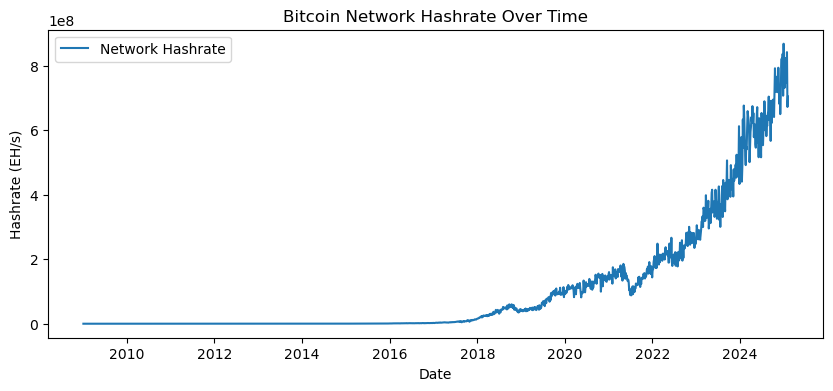

In [49]:
def plot_hashrate(df):
    """
    Plot Bitcoin hashrate over time.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Hashrate (EH/s)', label='Network Hashrate')
    plt.xlabel('Date')
    plt.ylabel('Hashrate (EH/s)')
    plt.title('Bitcoin Network Hashrate Over Time')
    plt.legend()
    plt.show()

plot_hashrate(hashrate_df)

Why does hashrate go up:

* increased popularity - more guesses per second 
* advances in hardware allowing for more hashes per second 
* increased mining difficulty - maintain the 10-min block time 

## Energy per Bitcoin Mined

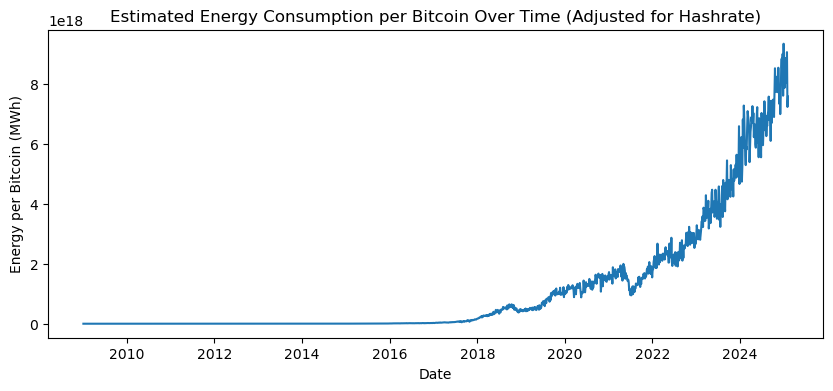

In [50]:
# Plot dynamic energy per Bitcoin mined over time accounting for hashrate
def plot_energy_over_time(df, block_reward=BLOCK_REWARD_BTC):
    """
    Plot estimated energy consumption per Bitcoin mined over time, accounting for hashrate changes.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    # Normalize energy consumption to hashrate changes
    initial_hashrate = df['Hashrate (EH/s)'].iloc[0]
    df['Relative Hashrate'] = df['Hashrate (EH/s)'] / initial_hashrate

    # Total energy scaled to hashrate growth
    df['Estimated Annual Energy (MWh)'] = (ENERGY_CONSUMPTION_TWH * 1e6) * df['Relative Hashrate']

    # Calculate estimated BTC mined per year
    annual_blocks = (60 / BLOCK_TIME_MINUTES) * 24 * 365  # Annual blocks mined
    df['Estimated BTC Mined'] = annual_blocks * block_reward

    # Calculate energy per BTC mined over time
    df['Energy per BTC (MWh)'] = df['Estimated Annual Energy (MWh)'] / df['Estimated BTC Mined']

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Energy per BTC (MWh)')
    plt.xlabel('Date')
    plt.ylabel('Energy per Bitcoin (MWh)')
    plt.title('Estimated Energy Consumption per Bitcoin Over Time (Adjusted for Hashrate)')
    plt.show()

plot_energy_over_time(hashrate_df)

## Network Security Growth

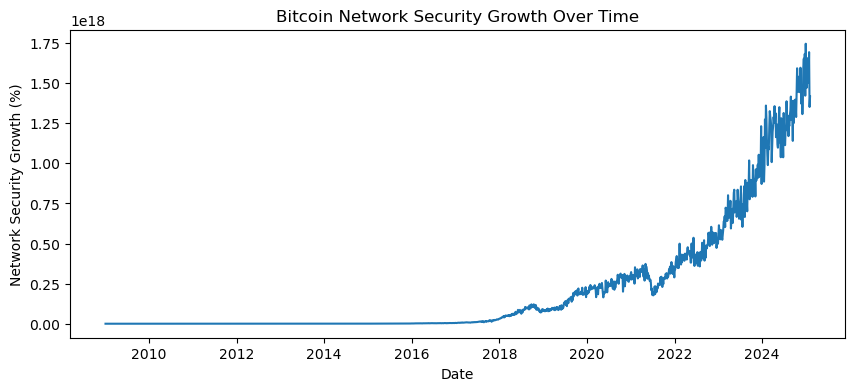

In [51]:
def plot_network_security(df):
    """
    Plot Bitcoin network security growth over time based on hashrate.
    Parameters: df (DataFrame) - Data with Date and Hashrate.
    Returns: None (Displays plot).
    """
    initial_hashrate = df['Hashrate (EH/s)'].iloc[0]
    df['Security Growth (%)'] = ((df['Hashrate (EH/s)'] - initial_hashrate) / initial_hashrate) * 100

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=df, x='Date', y='Security Growth (%)')
    plt.xlabel('Date')
    plt.ylabel('Network Security Growth (%)')
    plt.title('Bitcoin Network Security Growth Over Time')
    plt.show()

plot_network_security(hashrate_df)

Flat Growth (2009 - 2016): Early Mining Era: Mining was done on personal computers (CPUs) and later GPUs, resulting in low hashrate and security. Few miners contributed, keeping network security relatively weak.


Exponential Growth (2016 - 2024): 
* Introduction of ASICs around 2013-2014 led to rapid hashrate growth.
* Mining Farms: Large-scale mining operations significantly increased network power.
* Bitcoin Price Increases: Rising Bitcoin prices incentivized more miners to participate.

## Transaction Security based on confirmations and attacker hash

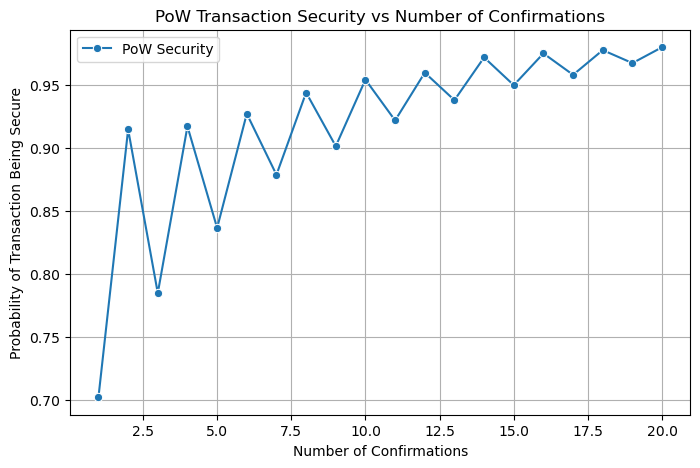

In [52]:
# Simulate PoW transaction security based on confirmations and attacker hashrate
def simulate_pow_transaction_security(num_confirmations=10, attacker_hashrate=0.3, num_simulations=10000):
    """
    Simulate PoW transaction security by estimating attack success probability.
    Parameters: num_confirmations (int), attacker_hashrate (float), num_simulations (int).
    Returns: Attack success probability (float).
    """
    attack_success_count = 0

    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attacker_hashrate)
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1

    attack_probability = attack_success_count / num_simulations
    return attack_probability



# Plot PoW transaction security over varying confirmation levels
def plot_pow_transaction_security():
    """
    Plot PoW transaction security across different confirmation levels.
    Returns: None (Displays plot).
    """
    confirmations = np.arange(1, 21)
    security_probs = [1 - simulate_pow_transaction_security(num_confirmations=n) for n in confirmations]

    plt.figure(figsize=(8, 5))
    sns.lineplot(x=confirmations, y=security_probs, marker='o', linestyle='-', label='PoW Security')
    plt.xlabel('Number of Confirmations')
    plt.ylabel('Probability of Transaction Being Secure')
    plt.title('PoW Transaction Security vs Number of Confirmations')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_pow_transaction_security()